# EDA & Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Overview

**Source & context:** This dataset is titled **FitBit Fitness Tracker Data** by arashnic on Kaggle. Thirty eligible Fitbit users consented to the submission of personal tracker data, including minute-level output for physical activity, heart rate, and sleep monitoring.

**Known limitations:** Only **30 users**, self-selected Mechanical Turk participants. Moreover, the data is from **2016**, not necessarily representative of the general population or of current step-tracking behavior.

This dataset came with many different files. Some with the same data, but sorted differently (e.g. daily, hourly, or by the minute). For my project, the core problem (early-warning: *"am I falling behind pace today, before it's too late to fix?"*) can't be answered by daily totals, since daily data only tells me the outcome *after* the day is over. Hourly data could work (smaller, easier to work with), but I've chosen minuteStepsNarrow_merged.csv over it instead, because hourly data smooths over the "short bursts" (like 10-minute walk between classes) that my real-life problem revolves around.

I've also chosen **Narrow** *(every row is a minute)* over **Wide** *(a column for every minute)* solely because it's tidy, pandas-standard data, making it very easy to work with.

I'll also use dailyActivity_merged.csv for validity cross-checking, and maybe to implement calorie regression later.

In [113]:
df = pd.read_csv('./data/raw/minuteStepsNarrow_merged.csv')

In [59]:
df['Id'].nunique()

33

The dataset info rounds down the number of users. There were actually 33 different tracked users.

In [3]:
df.head(10)

,Id,ActivityMinute,Steps
0,1503960366,4/12/2016 12:00:00 AM,0
1,1503960366,4/12/2016 12:01:00 AM,0
2,1503960366,4/12/2016 12:02:00 AM,0
3,1503960366,4/12/2016 12:03:00 AM,0
4,1503960366,4/12/2016 12:04:00 AM,0
5,1503960366,4/12/2016 12:05:00 AM,0
6,1503960366,4/12/2016 12:06:00 AM,0
7,1503960366,4/12/2016 12:07:00 AM,0
8,1503960366,4/12/2016 12:08:00 AM,0
9,1503960366,4/12/2016 12:09:00 AM,0


In [4]:
df.sample(10)

,Id,ActivityMinute,Steps
673445,4558609924,4/14/2016 12:05:00 PM,0
825185,5577150313,4/28/2016 8:05:00 AM,0
53502,1624580081,4/19/2016 6:42:00 AM,0
756667,4702921684,5/11/2016 3:07:00 PM,0
44728,1624580081,4/13/2016 4:28:00 AM,0
324419,2320127002,4/24/2016 7:59:00 PM,0
928291,6775888955,4/15/2016 5:31:00 AM,0
366273,2347167796,4/23/2016 6:33:00 AM,0
1094619,8053475328,4/19/2016 5:39:00 AM,0
226960,2022484408,4/18/2016 10:40:00 AM,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1325580 entries, 0 to 1325579
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   Id              1325580 non-null  int64 
 1   ActivityMinute  1325580 non-null  object
 2   Steps           1325580 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 30.3+ MB


In [6]:
df.shape

(1325580, 3)

## 2. Data Cleaning

Before I begin using and training on the data, I need to first check:
- **Cross-file consistency** - The dataset came with different files, some that track by days and others by minutes. The columns and their respective data should mostly match when merged.
- **Missing Values**
- **Duplicates** - In files such as minutestepsNarrow_merged.csv, each user should only have one step-count entry per exact minute.
- **Plausibility** - A step count is only "valid" if it's physically possible for a human. If any minute shows, say, 2,000 steps would be an obvious error or corrupted row, not just an outlier.
- **Correlation** - Columns like Steps and Calories should be meaningfully, positively correlated in real human data (more movement burns more calories)

**Cross-file consistency check:** merge both minuteStepsNarrow and dailyActivity by date, and compare the difference.

In [114]:
daily = pd.read_csv('./data/raw/dailyActivity_merged.csv')

In [8]:
daily.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [9]:
df['ActivityMinute'] = pd.to_datetime(df['ActivityMinute'], format='%m/%d/%Y %I:%M:%S %p')

In [13]:
df['ActivityDate'] = df['ActivityMinute'].dt.date # Getting just the date object to group steps by day

In [21]:
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'], format='%m/%d/%Y').dt.date

In [22]:
df.dtypes

Id                         int64
ActivityMinute    datetime64[ns]
Steps                      int64
ActivityDate              object
dtype: object

In [23]:
daily.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object

In [24]:
mins_daily = df.groupby(['Id', 'ActivityDate'])['Steps'].sum() # This gives me the total steps per day

In [25]:
merged = pd.merge(mins_daily, daily, how='inner', on=['Id', 'ActivityDate'])

In [26]:
merged['StepsDifference'] = merged['TotalSteps'] - merged['Steps']

In [39]:
merged.head()

,Id,ActivityDate,Steps,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,StepsDifference
0,1503960366,2016-04-12,13158,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,4
1,1503960366,2016-04-13,10735,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,0
2,1503960366,2016-04-14,10460,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,0
3,1503960366,2016-04-15,9685,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,77
4,1503960366,2016-04-16,12669,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,0


In [38]:
steps_nodiff = len(merged[merged['StepsDifference'] == 0])
steps_pct = round(steps_nodiff / len(merged) * 100)
print(f'{steps_pct}% ({steps_nodiff}/{len(merged)}) of the total steps per day from the minuteSteps file match with the dailyActivity file.')

83% (775/934) of the total steps per day from the minuteSteps file match with the dailyActivity file.


An 83% match isn't too bad, but still odd since they should rightfully match up correctly. Let's investigate why this is happening.

In [63]:
mismatches = merged[merged['StepsDifference'] != 0] # Getting only rows where the minute and daily data are dissonant

In [64]:
mismatches['StepsDifference'].describe()

count      159.000000
mean       662.522013
std       2053.896611
min          2.000000
25%         15.500000
50%         33.000000
75%        114.500000
max      12015.000000
Name: StepsDifference, dtype: float64

In [65]:
mismatches.sort_values('StepsDifference', ascending=False).head(10) # Checking the most prominent differences

,Id,ActivityDate,Steps,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,StepsDifference
866,8583815059,2016-05-03,0,12015,9.37,9.37,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,3212,12015
868,8583815059,2016-05-05,1507,12427,9.69,9.69,0.0,0.00,0.00,1.18,0.0,0,0,70,1370,3266,10920
604,6117666160,2016-04-21,9093,19542,15.01,15.01,0.0,0.98,0.40,5.62,0.0,11,19,294,579,4900,10449
410,4388161847,2016-04-12,0,10122,7.78,7.78,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,2955,10122
865,8583815059,2016-05-02,0,8469,6.61,6.61,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,2894,8469
379,4319703577,2016-04-12,0,7753,5.20,5.20,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,2115,7753
849,8583815059,2016-04-16,0,5319,4.15,4.15,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,2693,5319
411,4388161847,2016-04-13,5938,10993,8.45,8.45,0.0,0.06,0.63,3.88,0.0,1,14,150,1275,3092,5055
380,4319703577,2016-04-13,3619,8204,5.50,5.50,0.0,0.53,0.59,1.31,0.0,8,15,96,1234,2135,4585
867,8583815059,2016-05-04,0,3588,2.80,2.80,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,2516,3588


In [85]:
print(mismatches['Id'].nunique())
print(mismatches['Id'].value_counts()) # Checking if specific users have this issue more

31
Id
8877689391    26
8583815059    15
4020332650    15
7086361926    11
4319703577     9
2320127002     7
1503960366     7
1644430081     6
4445114986     5
1624580081     5
3977333714     5
4702921684     5
8053475328     4
5553957443     4
4558609924     4
5577150313     4
4388161847     3
6117666160     3
6775888955     3
2026352035     3
8378563200     3
2873212765     2
1844505072     2
2022484408     1
4057192912     1
6290855005     1
6962181067     1
8253242879     1
3372868164     1
8792009665     1
2347167796     1
Name: count, dtype: int64


In [72]:
total_days = merged.groupby('Id').size() # Gets the total days for each user
mismatch_counts = mismatches['Id'].value_counts()

round(((mismatch_counts / total_days) * 100)).sort_values(ascending=False)

Id
8877689391    84.0
8583815059    50.0
4020332650    48.0
7086361926    35.0
4319703577    29.0
4057192912    25.0
1503960366    23.0
2320127002    23.0
1644430081    20.0
3977333714    17.0
4445114986    16.0
4702921684    16.0
1624580081    16.0
4558609924    13.0
8053475328    13.0
5553957443    13.0
5577150313    13.0
6775888955    12.0
6117666160    11.0
4388161847    10.0
2026352035    10.0
8378563200    10.0
2873212765     6.0
1844505072     6.0
8253242879     6.0
2347167796     6.0
3372868164     5.0
6290855005     4.0
8792009665     4.0
2022484408     3.0
6962181067     3.0
1927972279     NaN
7007744171     NaN
dtype: float64

Mismatch rates vary sharply by user rather than being evenly distributed: 2 of 33 users have zero mismatches, while a small subset (e.g. 8877689391 at 84%, 8583815059 and 4020332650 at ~50%) show big, recurring disagreement between minute and daily totals.

In a separate check. I found that only 7 of the 159 mismatched rows co-occur with SedentaryMinutes = 1440 (a fully "inactive" day despite a nonzero step total), and this pattern doesn't even explain the worst offender (8877689391 has none of these rows at all), so it's a minor, secondary issue rather than the main cause.

This could most probably be a device syncing issue specific to those users. The remaining users show occasional, low-rate mismatches (typically under 30% of days) consistent with pretty minor, incidental sync gaps.

My best option would be to filter out users that pass a certain threshold on mismatched values (e.g. 50%) before training, since that could harm the prediction model's accuracy.

In [87]:
# Quick missing values and duplicate rows checks
print(df.isna().sum().sum())
print(df.duplicated().sum())

0
0


**Plausibility check:** no single minute should exceed 230 steps (a reasonable threshold for human running cadence)

In [81]:
print((df['Steps'] > 230).sum())

0


**Correlation check:** Steps and Calories should show a moderate positive correlation (0.50+) in the daily data (more movement burns more calories)

In [88]:
daily['TotalSteps'].corr(daily['Calories'])

np.float64(0.5915680862453355)

## 3. Exploratory Data Analysis

### 3.1 Distribution of Steps

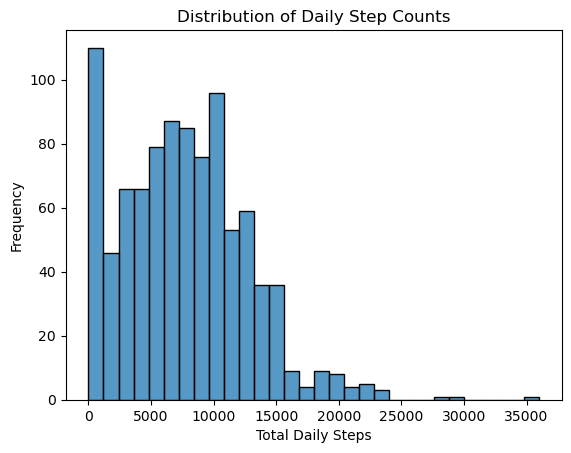

In [90]:
sns.histplot(daily['TotalSteps'], bins=30)
plt.xlabel('Total Daily Steps')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Step Counts')
plt.show()

In [100]:
print((daily['TotalSteps'] < 500).sum())
daily[daily['TotalSteps'] < 500].sample(5)

98


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
366,4020332650,2016-05-02,475,0.34,0.34,0.0,0.0,0.04,0.29,0.0,0,11,31,1350,2207
128,1927972279,2016-04-17,0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0,0,0,1440,2063
675,6775888955,2016-05-03,9,0.01,0.01,0.0,0.0,0.00,0.01,0.0,0,0,1,1439,1843
118,1844505072,2016-05-08,0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0,0,0,1440,1347
121,1844505072,2016-05-11,0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0,0,0,1440,1347


The plot illustrates a right-skewed distribution with a distinct spike near 0 steps, which may partly reflect device logging gaps identified earlier rather than true inactivity.

### 3.2 Daily/Hourly Patterns

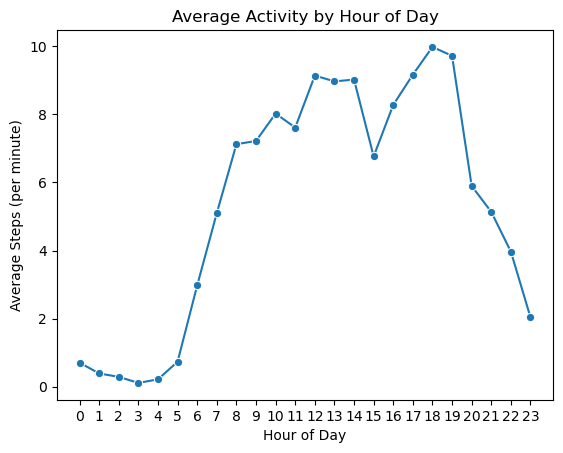

In [104]:
df['Hour'] = df['ActivityMinute'].dt.hour

hourly_avg = df.groupby('Hour')['Steps'].mean()

sns.lineplot(hourly_avg, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Steps (per minute)')
plt.title('Average Activity by Hour of Day')
plt.xticks(range(0, 24))
plt.show()

The plot illustrates a clear daily rhythm: lowest activity overnight (2–4am), rising through the morning, a brief dip around 3pm, and peaking in the early evening (~6pm) before declining.

### 3.3 Weekday vs Weekend Patterns

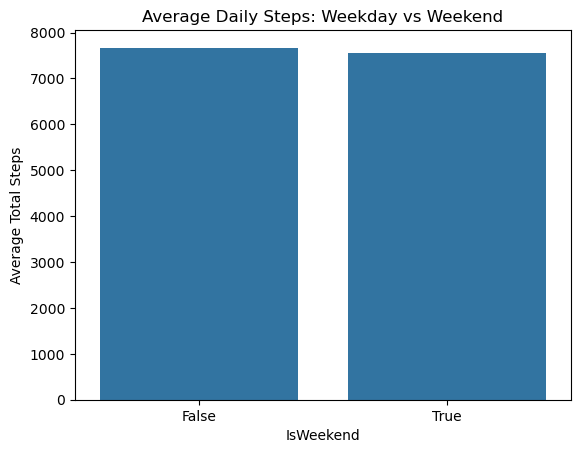

In [108]:
daily['DayOfWeek'] = pd.to_datetime(daily['ActivityDate']).dt.day_name()
daily['IsWeekend'] = daily['DayOfWeek'].isin(['Saturday', 'Sunday'])

weekend_avg = daily.groupby('IsWeekend')['TotalSteps'].mean()

sns.barplot(weekend_avg)
plt.ylabel('Average Total Steps')
plt.title('Average Daily Steps: Weekday vs Weekend')
plt.show()

Average steps are nearly identical between weekdays (~7,600) and weekends (~7,500) - a ~1.3% difference, suggesting no meaningful weekday/weekend activity pattern in this dataset.

### 3.4 User-Level Variation

In [109]:
daily.groupby('Id')['TotalSteps'].mean().describe()

count       33.000000
mean      7519.272678
std       3576.340125
min        916.129032
25%       5566.870968
50%       7282.966667
75%       9519.666667
max      16040.032258
Name: TotalSteps, dtype: float64

Average daily steps vary widely across users (from roughly 916 to 16040), confirming real individual differences in activity level.

### 3.5 Key Insights

- Daily step counts are right-skewed, with most days between ~5,000–13,000 steps and a spike near 0 that may partly reflect device logging gaps rather than true inactivity
- Activity follows a clear daily rhythm: lowest overnight (2–4am), rising through the morning, dipping briefly around 3pm, and peaking in the early evening (~6pm)
- Weekday and weekend activity are nearly identical (~7,600 vs ~7,500 steps), showing no meaningful weekly pattern in this dataset
- Average daily steps vary widely by user (from ~916 to ~16,040), confirming real individual differences in activity level
- Data validity checks (cross-file consistency, plausibility, correlation) confirmed the dataset is reliable overall, though a small subset of users show frequent minute-vs-daily mismatches likely due to device syncing issues, so these users may need to be handled carefully (or excluded) during modeling

## 4. Export Processed Dataset

In [112]:
df.to_csv('./data/processed_minute_steps.csv', index=False)
merged.to_csv('./data/processed_daily.csv', index=False)